In [1]:
import numpy as np
import pandas as pd
import time as time

In [2]:
df=pd.read_csv('Social_Network_Ads.xls')

In [3]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [4]:
df.drop('User ID',axis=1,inplace=True)

In [5]:
X=df[['Age','EstimatedSalary']]
y=df['Purchased']

In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
scaling=StandardScaler()
X_scaled=scaling.fit_transform(X)

In [8]:
X_scaled.shape

(400, 2)

In [9]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

In [10]:
model = Sequential()

model.add(Input(shape=(X_scaled.shape[1],)))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(loss=['binary_crossentropy'],metrics=['accuracy'])
history=model.fit(X_scaled,y,epochs=100,batch_size=1,validation_split=0.2)

Epoch 1/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8969 - loss: 0.2444 - val_accuracy: 0.9500 - val_loss: 0.1925
Epoch 2/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9094 - loss: 0.2496 - val_accuracy: 0.9625 - val_loss: 0.1719
Epoch 3/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9031 - loss: 0.2525 - val_accuracy: 0.9625 - val_loss: 0.1686
Epoch 4/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9000 - loss: 0.2505 - val_accuracy: 0.9625 - val_loss: 0.1675
Epoch 5/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9000 - loss: 0.2590 - val_accuracy: 0.9625 - val_loss: 0.1655
Epoch 6/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9062 - loss: 0.2630 - val_accuracy: 0.9500 - val_loss: 0.1628
Epoch 7/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9031 - loss: 0.2593 - val_accuracy: 0.9500 - val_loss: 0.1587
Epoch 8/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9031 - loss: 0.2609 - val_accu

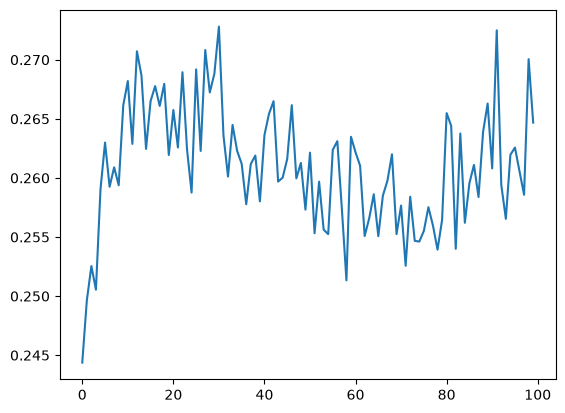

In [30]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])

In [31]:
history = model.fit(X_scaled,y,epochs=100,batch_size=100,validation_split=0.2)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.9125 - loss: 0.2570 - val_accuracy: 0.9625 - val_loss: 0.1619
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9125 - loss: 0.2558 - val_accuracy: 0.9625 - val_loss: 0.1632
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9125 - loss: 0.2538 - val_accuracy: 0.9625 - val_loss: 0.1661
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9125 - loss: 0.2524 - val_accuracy: 0.9625 - val_loss: 0.1688
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9125 - loss: 0.2508 - val_accuracy: 0.9625 - val_loss: 0.1722
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9125 - loss: 0.2494 - val_accuracy: 0.9625 - val_loss: 0.1761
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9125 - loss: 0.2473 - val_accuracy: 0.9625 - val_loss: 0.1775
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9125 - loss: 0.2461 - val_accuracy: 0.9500 - val_los

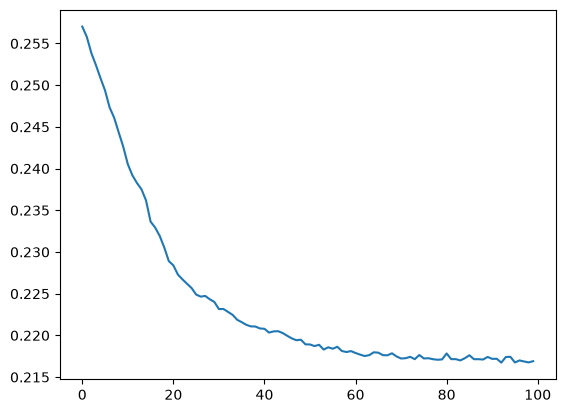

In [32]:
plt.plot(history.history['loss'])

In [35]:
history = model.fit(X_scaled,y,epochs=100,batch_size=400,validation_split=0.2)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.9062 - loss: 0.2146 - val_accuracy: 0.9375 - val_loss: 0.2460
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9062 - loss: 0.2146 - val_accuracy: 0.9375 - val_loss: 0.2497
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.9062 - loss: 0.2145 - val_accuracy: 0.9375 - val_loss: 0.2473
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9062 - loss: 0.2146 - val_accuracy: 0.9375 - val_loss: 0.2498
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9062 - loss: 0.2145 - val_accuracy: 0.9375 - val_loss: 0.2473
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.9062 - loss: 0.2145 - val_accuracy: 0.9375 - val_loss: 0.2503
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9062 - loss: 0.2145 - val_accuracy: 0.9375 - val_loss: 0.2464
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9062 - loss: 0.2145 - val_accuracy: 0.9375 - v

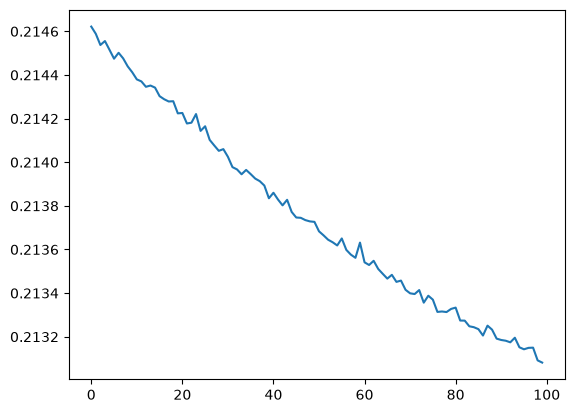

In [36]:
plt.plot(history.history['loss'])